## Overview
This notebook implements the model selection phase of the example. To explain the patterns of daily customer purchases
at the store we run PCA on the trimmed daily sales representation. There are many choices to explain variation and summarize
data. PCA is used here for illustration. Other choices such as support vector data description or matrix factorization based approaches
could be favored by some analysts or teams. The point here is that it is possible to capture annotations about rationale used
to make model selection decisions. This is done after developing the model and logging the observations to KMDS. The basic recipe in the note book is:
1. Read the data representation post the modelling choice decision to trim the representation to only use store inventory that accounts for daily variation - see the modelling choice notebook for details
2. Run PCA on the representation
3. Analyze the results
4. Log the observations with KMDS

## Read the Data

In [1]:
from importlib.resources import files
import pandas as pd
fp = str(files("kmds.examples").joinpath("retail_q1_post_mc.parquet"))
df = pd.read_parquet(fp)

In [2]:
df.shape

(75, 732)

## Run PCA

In [3]:
from sklearn.decomposition import PCA

In [4]:
retail_model = PCA(n_components=30)
df_transf = pd.DataFrame(retail_model.fit_transform(df))

In [5]:
retail_model1 = PCA(n_components=30)
df_transf2 = pd.DataFrame(retail_model.fit_transform(df.T))

In [6]:
df_transf2

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,5006.174462,341.610621,-200.696501,15.667096,-152.985438,296.664621,864.451470,-281.160715,132.160893,399.117864,...,-62.271525,-65.571788,287.868477,-102.833665,129.378591,141.058691,21.542853,167.912320,29.263007,91.783384
1,1681.468153,-460.558061,742.891866,116.278806,-423.577495,-241.718202,464.814056,222.851504,24.337049,354.965665,...,-178.978330,-29.235530,25.108104,-82.130558,359.113190,-134.986293,-80.636030,-76.519844,-285.815938,76.015996
2,957.268797,48.728754,374.343841,395.763263,-316.445497,-195.200826,202.106244,143.163359,-262.361132,97.813543,...,363.545525,-56.982126,-400.126560,-211.431662,-83.619816,-58.400075,63.128575,16.383109,246.870283,109.809041
3,1410.624104,-342.473654,-87.784548,165.448361,-400.123006,-603.724194,-567.342350,222.550501,-150.956682,-259.504043,...,28.555724,93.034364,144.285232,65.724949,-37.940127,45.389076,-204.691795,-5.941680,-195.534809,-260.484436
4,1677.514031,-239.064096,-520.944725,-200.779124,354.019232,49.164778,-99.419459,21.642191,-70.933313,-273.816809,...,-175.201870,-109.860217,-289.040861,-50.991710,-204.120416,-5.170581,31.731409,-382.232154,-159.623619,-3.290898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,-172.852245,2.100378,-27.136271,-9.633866,34.745149,8.779199,77.545281,150.249722,27.825843,23.477556,...,-6.105516,14.376116,11.852438,-3.043652,-0.694769,0.005681,4.894453,11.471065,-4.787589,5.352210
728,-159.148451,67.923017,-17.423769,-32.287587,-21.937179,74.068222,-14.957356,-42.938774,49.574483,-10.803168,...,12.523653,-7.071207,-33.169297,-27.307353,-3.816928,10.178852,-28.722871,-6.771889,-21.455367,-25.459087
729,-177.155884,-5.836932,-21.174298,-34.276648,44.268195,-0.042000,-47.146123,-18.385842,9.499260,26.337634,...,-67.301460,-185.314465,12.861713,230.133254,73.083291,-217.724937,244.588454,-63.354371,-18.584647,-115.167342
730,-182.902087,10.916987,-38.173582,-33.872564,21.799248,-1.593673,1.862832,-52.009991,-15.474639,-6.473867,...,0.612654,18.158208,-50.641096,1.897448,14.482212,30.401944,14.806794,85.394257,-93.032567,2.650520


In [7]:
fp = str(files("kmds.examples").joinpath("retail_transformed_q1_product_data.parquet"))
df_transf2.columns = ["c_" + str(i+1) for i in range(df_transf.shape[1])]
df_transf2.to_parquet(fp, index=False)

In [8]:
fp = str(files("kmds.examples").joinpath("retail_transformed_q1_sales_data.parquet"))
df_transf.columns = ["c_" + str(i+1) for i in range(df_transf.shape[1])]
df_transf.to_parquet(fp, index=False)

In [9]:
 retail_model.explained_variance_ratio_.cumsum()

array([0.16927973, 0.25284967, 0.33298209, 0.39949308, 0.45306245,
       0.4975023 , 0.53758732, 0.57516627, 0.6030706 , 0.62816856,
       0.65140386, 0.67159257, 0.69093234, 0.70955166, 0.72759461,
       0.74498374, 0.75977557, 0.77413649, 0.78797331, 0.80042218,
       0.81132696, 0.82182768, 0.83156227, 0.84061709, 0.84909018,
       0.85701055, 0.86438486, 0.87144621, 0.87823383, 0.88485293])

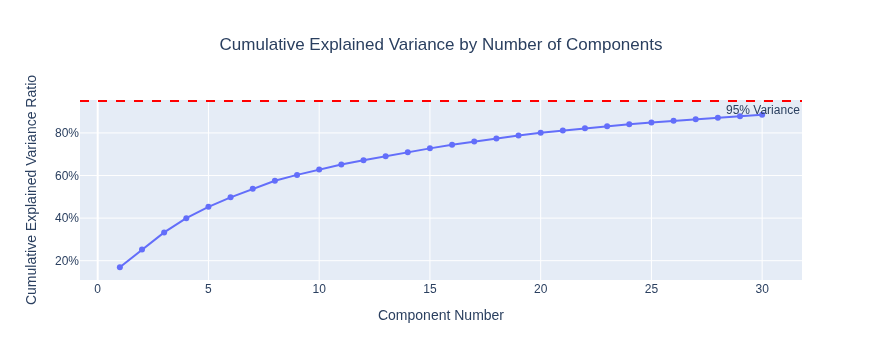

In [10]:
import plotly.express as px
import numpy as np

# Calculate the cumulative sum of the explained variance ratio
# I'm assuming your fitted PCA object is named 'pca'
# If it's named something else, please replace 'pca' with your variable name.
cumulative_variance = np.cumsum(retail_model.explained_variance_ratio_)

# Create the line plot
fig = px.line(
    x=range(1, len(cumulative_variance) + 1),
    y=cumulative_variance,
    markers=True,
    labels={
        "x": "Component Number",
        "y": "Cumulative Explained Variance Ratio"
    },
    title="Cumulative Explained Variance by Number of Components"
)

# Improve the layout and add a reference line for 95% variance
fig.update_layout(
    yaxis=dict(tickformat=".0%"), # Format y-axis ticks as percentages
    xaxis=dict(title="Component Number"),
    title_x=0.5, # Center the title
    showlegend=False
)

# Add a horizontal line to indicate a common threshold, like 95%
fig.add_hline(y=0.95, line_dash="dash", line_color="red", annotation_text="95% Variance", 
              annotation_position="bottom right")

# Show the interactive plot
fig.show()

## Log the Observations to KMDS

In [11]:
from kmds.tagging.tag_types import *
from owlready2 import *
from kmds.utils.load_utils import *
from kmds.utils.path_utils import *
KNOWLEDGE_BASE = str(files("kmds.examples").joinpath("example_ml_kb_exp_workflow.xml"))


* Owlready2 * Warning: optimized Cython parser module 'owlready2_optimized' is not available, defaulting to slower Python implementation


In [12]:
onto2 = load_kb(KNOWLEDGE_BASE)
with onto2:
    insts = Workflow.instances()
the_workflow_instance = insts[0]

In [13]:
the_workflow_instance

example_ml_kb_exp_workflow.xml.retail_customer_modelling

In [14]:
summary_string = """
To interpret PCA results for store inventory, analyze the 'loadings' (the coefficients of the original variables) for each principal component. These are stored in the `.components_` attribute of a fitted scikit-learn PCA object.

The core workflow is as follows:

1.  **Create a Loadings DataFrame**: Convert the `pca.components_` numpy array into a pandas DataFrame for easier analysis. The columns should be the original features (inventory items) and the index should be the principal components (PC1, PC2, ...).
    
    `loadings_df = pd.DataFrame(pca.components_, columns=inventory_item_names, index=[f'PC{i+1}' for i in range(n_components)])`

2.  **Profile Each Component**: For each principal component (i.e., each row in `loadings_df`), sort the values to find the items with the largest absolute loadings.
    
    `pc1_sorted_loadings = loadings_df.loc['PC1'].sort_values(ascending=False)`

3.  **Interpret the Meaning**:
    *   **High Absolute Value**: Items with high absolute loadings are the most important drivers of that component.
    *   **Sign (Positive vs. Negative)**: Items with large positive loadings vary together. Items with large negative loadings also vary together. Items with opposite signs on the same component represent a contrast or trade-off in the data (e.g., 'summer items' vs. 'winter items'). By examining these groups, you can assign a business meaning to the abstract component.
"""


In [15]:
from kmds.ontology.intent_types import IntentType
ms_obs_list = []
observation_count = 1

ms1 = ModelSelectionObservation(namespace=onto2)
ms1.finding = summary_string
ms1.finding_sequence = observation_count
ms1.model_selection_observation_type = ModelSelectionTags.MODEL_SELECTION_STATEMENT.value
ms1.intent = IntentType.MODEL_SELECTION.value
ms_obs_list.append(ms1)
the_workflow_instance.has_model_selection_observations = ms_obs_list
onto2.save(file=KNOWLEDGE_BASE, format="rdfxml")